In [16]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split

torch.manual_seed(42)

---

### 1. Redes multicapa con nn.Module

In [17]:
# Datos de XOR
X = torch.tensor([[0., 0.],
                  [0., 1.],
                  [1., 0.],
                  [1., 1.]])

y = torch.tensor([[0.],
                  [1.],
                  [1.],
                  [0.]])


class MLP(nn.Module):
    def __init__(self, use_activation=True):
        super(MLP, self).__init__()
        self.hidden = nn.Linear(2, 8)
        self.output = nn.Linear(8, 1)
        self.activation = nn.Tanh() if use_activation else nn.Identity()

    def forward(self, x):
        return self.output(self.activation(self.hidden(x)))

def train_model(model, X, y, epochs=2000, lr=0.05):
    loss_fn = nn.BCEWithLogitsLoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for _ in range(epochs):
        opt.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses

def model_accuracy(model, X, y):
    with torch.no_grad():
        pred = (model(X) > 0).float() 
    return (pred == y).float().mean().item()

def plot(model, X, y):
    g = torch.linspace(-0.5, 1.5, 200)
    xx, yy = torch.meshgrid(g, g, indexing='xy')
    grid = torch.stack([xx.ravel(), yy.ravel()], dim=1)
    with torch.no_grad():
        prob = torch.sigmoid(model(grid)).reshape(xx.shape)
    plt.contourf(xx.numpy(), yy.numpy(), prob.numpy(), levels=[0, 0.5, 1],
                 colors=['#a6cee3', '#fb9a99'], alpha=0.6)
    plt.contour(xx.numpy(), yy.numpy(), prob.numpy(), levels=[0.5], colors='k')
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze().numpy(), cmap='coolwarm',
                edgecolors='k', s=150)
    plt.show()

Pérdida final: 0.0000
Exactitud: 100%


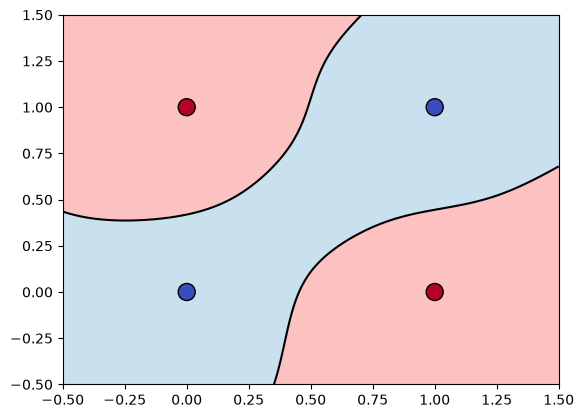

In [18]:
mlp = MLP()
loss_mlp = train_model(mlp, X, y)

print(f'Pérdida final: {loss_mlp[-1]:.4f}')
print(f'Exactitud: {model_accuracy(mlp, X, y) * 100:.0f}%')
plot(mlp, X, y)

Pérdida final: 0.6931
Exactitud: 50%


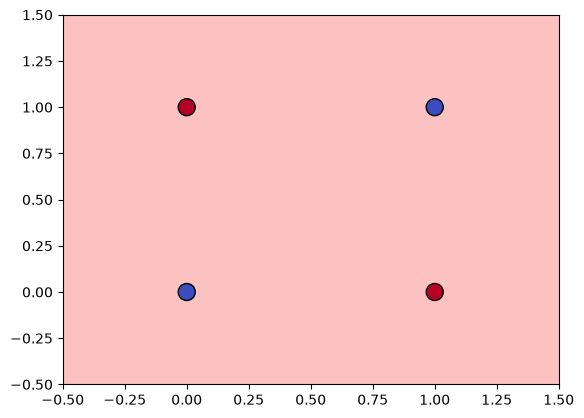

In [19]:
# Version sin función de activación entre las capas

mlp_lineal = MLP(use_activation=False)
perdidas_lineal = train_model(mlp_lineal, X, y)

print(f'Pérdida final: {perdidas_lineal[-1]:.4f}')
print(f'Exactitud: {model_accuracy(mlp_lineal, X, y) * 100:.0f}%')
plot(mlp_lineal, X, y)


**¿Por que apilar capas lineales equivale a una sola capa lineal?**

Como el producto de dos matrices es otra matriz y la combinacion de dos sesgos equivale a otro sesgo, no importa cuantas capas se apliquen, el modelo seguira siendo una unica rtansformacion lineal y solo puede producir una frontera de decision recta. Ademas, XOR no es linealmente separable, asi que una recta nunca va a poder clasificar bien los 4 puntos.

In [20]:
# Red de la diapositiva: entrada 3, dos capas ocultas de 4, salida 2
network = nn.Sequential(
    nn.Linear(3, 4),
    nn.ReLU(),
    nn.Linear(4, 4),
    nn.ReLU(),
    nn.Linear(4, 2),
)

total = sum(p.numel() for p in network.parameters())
print(f'\nTotal de parámetros: {total} \n')

for name, p in network.named_parameters():
    print(f'{name:10s} shape = {str(tuple(p.shape)):8s} elements = {p.numel()}')


Total de parámetros: 46 

0.weight   shape = (4, 3)   elements = 12
0.bias     shape = (4,)     elements = 4
2.weight   shape = (4, 4)   elements = 16
2.bias     shape = (4,)     elements = 4
4.weight   shape = (2, 4)   elements = 8
4.bias     shape = (2,)     elements = 2


---

### 2. Funciones de activación

In [21]:
z = torch.linspace(-5, 5, 200, requires_grad=True)

sig = torch.sigmoid(z)
tanh = torch.tanh(z)
relu = torch.relu(z)

d_sig = torch.autograd.grad(sig.sum(), z)[0]
d_tanh = torch.autograd.grad(tanh.sum(), z)[0]
d_relu = torch.autograd.grad(relu.sum(), z)[0]

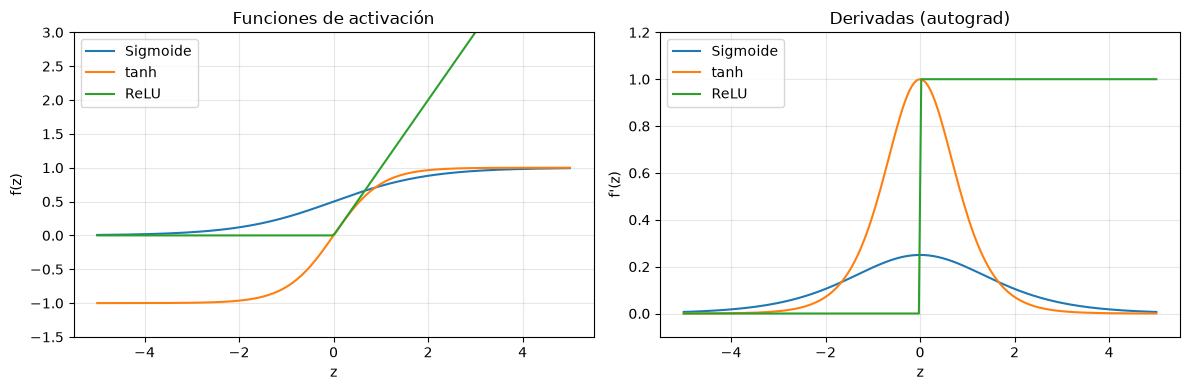

In [22]:
zn = z.detach().numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Funciones
ax1.plot(zn, sig.detach().numpy(), label='Sigmoide')
ax1.plot(zn, tanh.detach().numpy(), label='tanh')
ax1.plot(zn, relu.detach().numpy(), label='ReLU')
ax1.set_title('Funciones de activación')
ax1.set_xlabel('z')
ax1.set_ylabel('f(z)')
ax1.set_ylim(-1.5, 3)
ax1.grid(alpha=0.3)
ax1.legend()

# Derivadas calculadas con autograd
ax2.plot(zn, d_sig.numpy(), label="Sigmoide")
ax2.plot(zn, d_tanh.numpy(), label="tanh")
ax2.plot(zn, d_relu.numpy(), label="ReLU")
ax2.set_title('Derivadas (autograd)')
ax2.set_xlabel('z')
ax2.set_ylabel("f'(z)")
ax2.set_ylim(-0.1, 1.2)
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

**¿En qué regiones se desvanece el gradiente de la sigmoide y de tanh?**

En las dos funciones el gradiente se desvanece en las colas cuando |z| es grande y la función se satura. En la sigmoide su derivada vale máximo ~0.25 en z = 0 y se acerca a 0 cuando |z| es mayor a 4 aproximadamente. En tanh la derivada vale máximo 1 en z = 0 y se acerca a 0 cuando |z| es mayor a 3 aproximadamente. Como en la retropropagación estas derivadas se multiplican capa por capa, el gradiente de las primeras capas se vuelve casi cero y dejan de "aprender".

**¿Por qué ReLU es la opción por defecto en capas ocultas?**

Porque su derivada es 1 para todo z > 0, así que no se satura en esa región y el gradiente no se encoge al pasar por varias capas. Además de esto, es barata de calcular y sigue siendo no lineal, por lo que permite aprender fronteras como la de XOR.

---

### 3. Pérdida, optimizador y ciclo de entrenamiento

In [27]:
iris = load_iris()
X_all, y_all = iris.data, iris.target

X_tr, X_val, y_tr, y_val = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)

mean = X_tr.mean(axis=0)
std = X_tr.std(axis=0)
X_tr = (X_tr - mean) / std
X_val = (X_val - mean) / std

X_tr = torch.tensor(X_tr, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_tr = torch.tensor(y_tr, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

In [28]:
class IrisMLP(nn.Module):
    def __init__(self, in_dim=4, hidden_dim=8, out_dim=3):
        super().__init__()
        self.hidden = nn.Linear(in_dim, hidden_dim)
        self.act = nn.ReLU()
        self.output = nn.Linear(hidden_dim, out_dim)

    def forward(self, x):
        return self.output(self.act(self.hidden(x)))


torch.manual_seed(42)
model = IrisMLP()
total = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nTotal de parámetros: {total}')

IrisMLP(
  (hidden): Linear(in_features=4, out_features=8, bias=True)
  (act): ReLU()
  (output): Linear(in_features=8, out_features=3, bias=True)
)

Total de parámetros: 67


In [29]:
def train_iris(model, optimizer, epochs=500):
    loss_fn = nn.CrossEntropyLoss()
    record = []
    for epoch in range(epochs):
        model.train()
        logits = model(X_tr)
        loss = loss_fn(logits, y_tr)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        record.append(loss.item())
    return record

**¿Por qué la red no debe tener softmax en su última capa cuando se usa nn.CrossEntropyLoss?**

La red no deberia de tener softmax en su ultima capa porque `nn.CrossEntropyLoss` ya aplcia intermanente `log_softmax`,  seguido de la pérdida negativa de log-verosimilitud, así que espera logits sin normalizar. Si la red tuviera un softmax al final, se terminaria aplicando 2 veces, lo que aplanaria las probabilidades y distorsionaria el gradiente, haciendo el entrenamiento más lento.

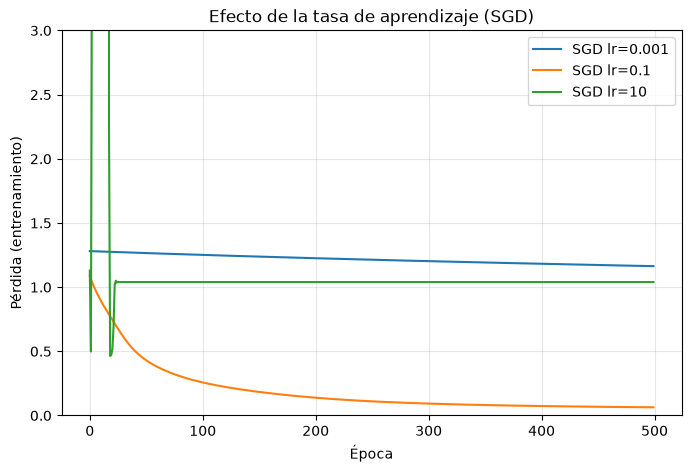

SGD lr=0.001    pérdida final: 1.1638
SGD lr=0.1      pérdida final: 0.0637
SGD lr=10       pérdida final: 1.0398


In [30]:
learning_rates = [0.001, 0.1, 10]
record = {}
modelos = {}

for lr in learning_rates:
    m = IrisMLP()
    opt = torch.optim.SGD(m.parameters(), lr=lr)
    name = f'SGD lr={lr}'
    record[name] = train_iris(m, opt)
    modelos[name] = m

plt.figure(figsize=(8, 5))
for name, h in record.items():
    plt.plot(h, label=name)
plt.ylim(0, 3)
plt.xlabel('Época')
plt.ylabel('Pérdida (entrenamiento)')
plt.title('Efecto de la tasa de aprendizaje (SGD)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

for name, h in record.items():
    print(f'{name:15s} pérdida final: {h[-1]:.4f}')

**De las 3 tasas de aprendizaje (0.001, 0.1 y 10), ¿cual aprende demasiado lento, cual converge y cual diverge?**

